<a href="https://colab.research.google.com/github/ikhyun00/project/blob/main/Kaggle_%EC%8B%9C%ED%97%98%EC%A0%90%EC%88%98%EC%98%88%EC%B8%A1_%EB%A9%94%EC%9D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd

DATA_PATH = '/content/drive/MyDrive/멀티캠퍼스/4_머신러닝_딥러닝/프로젝트 회귀/'

df = pd.read_csv(DATA_PATH + 'data/train.csv')

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm


In [ ]:
# ============================================================
# 0) 설정
# ============================================================
OUT_DIR = "outputs_study_hours_only"
os.makedirs(OUT_DIR, exist_ok=True)

TOP_K_COURSE = 20
TOP_K_STUDY_METHOD = 20

# t-test는 그룹 균형 샘플링
TTEST_N_YES = 60
TTEST_N_NO  = 40

# ANOVA 샘플 수 샘플링
ANOVA_N = 600
RANDOM_STATE = 42

In [ ]:
# ============================================================
# 1) 유틸 함수
# ============================================================
def normalize_str_series(s):
    if not pd.api.types.is_string_dtype(s):
        return s
    return s.astype(str).str.strip().str.lower().replace({"nan": np.nan})

def try_make_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def reduce_to_top_k(df, col, k):
    if col not in df.columns:
        return df
    top = df[col].value_counts(dropna=True).head(k).index
    df[col] = df[col].where(df[col].isin(top), other="other")
    return df

def cohen_d(x, y):
    x, y = pd.Series(x).dropna().astype(float), pd.Series(y).dropna().astype(float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled = ((nx-1)*vx + (ny-1)*vy) / (nx+ny-2)
    if pooled <= 0:
        return np.nan
    return float((x.mean() - y.mean()) / np.sqrt(pooled))

def eta_squared(aov, effect):
    if effect not in aov.index or "sum_sq" not in aov.columns:
        return np.nan
    ss_total = aov["sum_sq"].sum()
    if ss_total == 0:
        return np.nan
    return float(aov.loc[effect, "sum_sq"] / ss_total)

def omega_squared(aov, effect):
    if effect not in aov.index:
        return np.nan
    ss_effect = aov.loc[effect, "sum_sq"]
    df_effect = aov.loc[effect, "df"]
    ss_error = aov.loc["Residual", "sum_sq"]
    df_error = aov.loc["Residual", "df"]
    ms_error = ss_error / df_error
    ss_total = aov["sum_sq"].sum()
    w2 = (ss_effect - df_effect * ms_error) / (ss_total + ms_error)
    return float(max(0.0, w2))

In [ ]:
# ============================================================
# 2) 전처리
# ============================================================
for drop_col in ["id", "ID", "Id", "index", "exam_score"]:
    if drop_col in df.columns:
        df = df.drop(columns=[drop_col])

df = try_make_numeric(df, ["age", "study_hours", "sleep_hours", "class_attendance"])

for c in ["gender", "course", "internet_access", "sleep_quality",
          "study_method", "facility_rating", "exam_difficulty"]:
    if c in df.columns:
        df[c] = normalize_str_series(df[c])

ORDERS = {
    "sleep_quality": ["poor", "average", "good"],
    "facility_rating": ["low", "medium", "high"],
    "exam_difficulty": ["easy", "moderate", "hard"]
}
for col, order in ORDERS.items():
    if col in df.columns:
        df[col] = pd.Categorical(df[col], categories=order, ordered=True)

df = reduce_to_top_k(df, "course", TOP_K_COURSE)
df = reduce_to_top_k(df, "study_method", TOP_K_STUDY_METHOD)

df = df.drop_duplicates()

print("Cleaned shape:", df.shape)

df_base = df.dropna(subset=["study_hours"]).copy()

Cleaned shape: (630000, 11)


In [ ]:
# ============================================================
# 3) t-test: internet_access (균형 샘플링)
# ============================================================
t_df = pd.DataFrame()

if "internet_access" in df_base.columns:
    dft_all = df_base[["study_hours", "internet_access"]].dropna().copy()
    dft_all = dft_all[dft_all["internet_access"].isin(["yes", "no"])]

    yes_pool = dft_all[dft_all["internet_access"] == "yes"]
    no_pool  = dft_all[dft_all["internet_access"] == "no"]

    n_yes = min(TTEST_N_YES, len(yes_pool))
    n_no  = min(TTEST_N_NO,  len(no_pool))

    print(f"[t-test] pool sizes: yes={len(yes_pool)}, no={len(no_pool)}")
    print(f"[t-test] sampled: yes={n_yes}, no={n_no}")

    if n_yes >= 2 and n_no >= 2:
        yes_s = yes_pool.sample(n=n_yes, random_state=RANDOM_STATE)["study_hours"]
        no_s  = no_pool.sample(n=n_no,  random_state=RANDOM_STATE)["study_hours"]

        tt = stats.ttest_ind(yes_s, no_s, equal_var=False)

        t_df = pd.DataFrame([{
            "dv": "study_hours",
            "group": f"internet_access (yes {n_yes} vs no {n_no})",
            "n_yes": int(n_yes),
            "n_no": int(n_no),
            "mean_yes": float(yes_s.mean()),
            "mean_no": float(no_s.mean()),
            "t": float(tt.statistic),
            "p": float(tt.pvalue),
            "cohen_d": float(cohen_d(yes_s, no_s)),
        }])
    else:
        print("[SKIP t-test] yes/no 표본이 너무 적습니다.")

t_path = os.path.join(OUT_DIR, "t_test_results_balanced.csv")
t_df.to_csv(t_path, index=False)

print("\n=== [T-TEST RESULT] ===")
display(t_df)
print("Saved:", t_path)

[t-test] pool sizes: yes=579423, no=50577
[t-test] sampled: yes=60, no=40

=== [T-TEST RESULT] ===


,dv,group,n_yes,n_no,mean_yes,mean_no,t,p,cohen_d
0,study_hours,internet_access (yes 60 vs no 40),60,40,3.865333,4.218,-0.772421,0.441859,-0.153226


Saved: outputs_study_hours_only/t_test_results_balanced.csv


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# =========================
# 설정
# =========================
DV = "study_hours"
IV = "internet_access"   # yes/no
GROUPS = ["no", "yes"]   # 데이터 실제 값에 맞춰서
ALPHA = 0.05

N_GRID = [20, 30, 50, 100, 200, 500, 1000, 2000]  # 각 그룹 샘플 수 후보
N_REPEATS = 200
RANDOM_SEED = 42

# "최적" 기준(원하는대로 조정)
TARGET_POWER = 0.90          # p<0.05가 90% 이상
TARGET_MEANDIFF_MIN = None   # 예: 0.10(시간) = 6분. 기준 없으면 None

# =========================
# 데이터 준비
# =========================
d = df[[DV, IV]].dropna().copy()
d[DV] = pd.to_numeric(d[DV], errors="coerce")
d = d.dropna(subset=[DV])
d[IV] = d[IV].astype(str).str.lower()

print("[Full counts]")
print(d[IV].value_counts())

# 그룹별 최소 크기
counts = d[IV].value_counts()
min_group = int(counts.reindex(GROUPS).min())
print("min_group:", min_group)

# =========================
# 효과크기 Cohen's d (Welch용으로는 보통 pooled SD 사용)
# =========================
def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    sp = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    if sp == 0:
        return 0.0
    return (x.mean() - y.mean()) / sp

# =========================
# 반복 층화 샘플링 평가
# =========================
rng = np.random.default_rng(RANDOM_SEED)
rows = []

for n in N_GRID:
    n_use = min(n, min_group)  # 부족하면 가능한 최대치로 자동 축소(비복원)
    for r in range(N_REPEATS):
        seed = int(rng.integers(0, 1_000_000))

        s0 = d[d[IV] == GROUPS[0]].sample(n=n_use, replace=False, random_state=seed)[DV].astype(float)
        s1 = d[d[IV] == GROUPS[1]].sample(n=n_use, replace=False, random_state=seed)[DV].astype(float)

        # Welch t-test
        stat, p = ttest_ind(s0, s1, equal_var=False)

        meandiff = float(s1.mean() - s0.mean())  # yes - no (원하는 방향으로 바꿔도 됨)
        d_eff = float(cohens_d(s1, s0))

        rows.append({
            "n_per_group": n_use,
            "rep": r,
            "p": float(p),
            "meandiff_hours": meandiff,
            "meandiff_minutes": meandiff * 60.0,
            "cohens_d": d_eff
        })

res = pd.DataFrame(rows)

summary = (
    res.groupby("n_per_group")
       .agg(
           power=("p", lambda x: float((x < ALPHA).mean())),
           meandiff_med_min=("meandiff_minutes", "median"),
           meandiff_p05_min=("meandiff_minutes", lambda x: float(np.quantile(x, 0.05))),
           meandiff_p95_min=("meandiff_minutes", lambda x: float(np.quantile(x, 0.95))),
           d_med=("cohens_d", "median"),
       )
       .reset_index()
)

summary["meandiff_ci_width_90_min"] = summary["meandiff_p95_min"] - summary["meandiff_p05_min"]

print("\n=== [t-test stratified sampling summary] ===")
display(summary)

# =========================
# "최적 n" 선택: 조건 만족하는 최소 n
# =========================
cond = (summary["power"] >= TARGET_POWER)
if TARGET_MEANDIFF_MIN is not None:
    cond = cond & (summary["meandiff_med_min"] >= TARGET_MEANDIFF_MIN)

candidates = summary[cond].sort_values("n_per_group")

if len(candidates) == 0:
    print("\n[RESULT] 현재 그리드에서 기준을 만족하는 n이 없습니다.")
    print(" - 해결: N_GRID에 더 큰 값 추가, TARGET_POWER 낮추기, 또는 효과 기준 완화")
else:
    best = candidates.iloc[0]
    print("\n[RESULT] 권장 샘플 수(각 그룹):", int(best["n_per_group"]))
    print(best)


[Full counts]
internet_access
yes    579423
no      50577
Name: count, dtype: int64
min_group: 50577

=== [t-test stratified sampling summary] ===


,n_per_group,power,meandiff_med_min,meandiff_p05_min,meandiff_p95_min,d_med,meandiff_ci_width_90_min
0,20,0.075,1.92000,-84.44100,76.48200,0.013712,160.92300
1,30,0.035,-0.65000,-59.90200,51.60100,-0.004509,111.50300
2,50,0.065,-3.64200,-56.26200,40.46100,-0.025224,96.72300
3,100,0.075,-2.49000,-40.26360,29.17710,-0.017632,69.44070
4,200,0.055,-2.76150,-25.85190,18.61230,-0.019578,44.46420
5,500,0.070,-3.12240,-17.97900,11.33388,-0.021728,29.31288
6,1000,0.040,-2.72826,-11.47125,8.20590,-0.019134,19.67715
7,2000,0.105,-2.94480,-11.22915,3.94587,-0.020741,15.17502



[RESULT] 현재 그리드에서 기준을 만족하는 n이 없습니다.
 - 해결: N_GRID에 더 큰 값 추가, TARGET_POWER 낮추기, 또는 효과 기준 완화



=== [CI RESULT] ===


,dv,group1,group2,alpha,mean_yes,mean_yes_ci_low,mean_yes_ci_high,n_yes,mean_no,mean_no_ci_low,mean_no_ci_high,n_no,mean_diff(yes-no),diff_ci_low,diff_ci_high,welch_df
0,study_hours,internet_access=yes,internet_access=no,0.05,3.865333,3.239072,4.491595,60,4.218,3.545608,4.890392,40,-0.352667,-1.259548,0.554214,91.342151


Saved: outputs_study_hours_only/t_test_ci_welch.csv


/tmp/ipython-input-3521972230.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_yes, data_no], labels=["yes", "no"], showmeans=True)


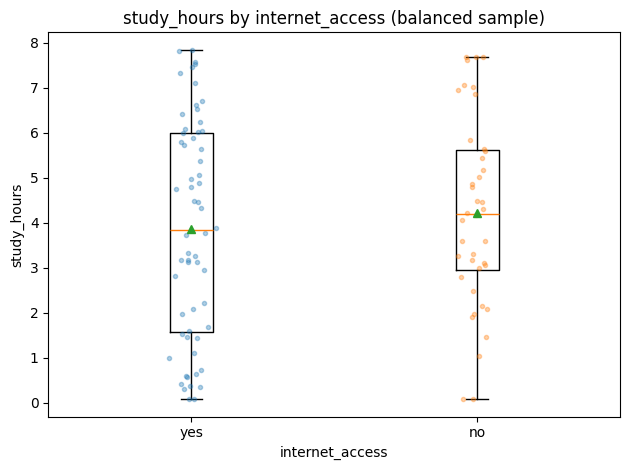

Saved: outputs_study_hours_only/boxplot_study_hours_internet_access.png


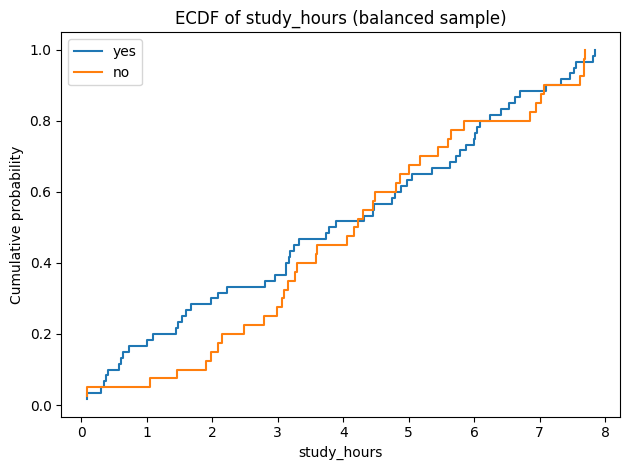

Saved: outputs_study_hours_only/ecdf_study_hours_internet_access.png


In [ ]:
# ============================================================
# 4) 신뢰구간 + 시각화(박스플롯, 누적분포 ECDF)
#    - Welch t-test 기준 (equal_var=False와 일관)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

ALPHA = 0.05  # 95% CI

# (중요) 위 블록에서 yes_s, no_s가 만들어졌다는 가정
# 만약 scope 문제로 에러나면, 위 t-test 코드에서 yes_s/no_s를
# if문 밖에서 선언해두는 방식으로 바꿔줘 (예: yes_s=None; no_s=None)

def mean_ci_t(x, alpha=0.05):
    """단일 표본 평균의 t-기반 CI"""
    x = pd.Series(x).dropna().astype(float)
    n = x.size
    m = x.mean()
    s = x.std(ddof=1)
    se = s / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    lo = m - tcrit * se
    hi = m + tcrit * se
    return float(m), int(n), float(lo), float(hi)

def welch_mean_diff_ci(x, y, alpha=0.05):
    """
    Welch (equal_var=False) 기준
    mean(x)-mean(y)의 CI + df
    """
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)

    nx, ny = x.size, y.size
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)

    diff = mx - my
    se = np.sqrt(vx/nx + vy/ny)

    # Welch-Satterthwaite df
    df = (vx/nx + vy/ny)**2 / ((vx**2)/((nx**2)*(nx-1)) + (vy**2)/((ny**2)*(ny-1)))

    tcrit = stats.t.ppf(1 - alpha/2, df=df)
    lo = diff - tcrit * se
    hi = diff + tcrit * se
    return float(diff), float(lo), float(hi), float(df)

def ecdf(a):
    a = pd.Series(a).dropna().astype(float).to_numpy()
    a = np.sort(a)
    y = np.arange(1, len(a) + 1) / len(a)
    return a, y

# ---- 신뢰구간 계산 ----
if "yes_s" in globals() and "no_s" in globals() and (yes_s is not None) and (no_s is not None):
    # 집단 평균 CI
    mean_yes, n_yes_ci, lo_yes, hi_yes = mean_ci_t(yes_s, alpha=ALPHA)
    mean_no,  n_no_ci,  lo_no,  hi_no  = mean_ci_t(no_s,  alpha=ALPHA)

    # 평균 차이 CI (Welch)
    diff, lo_diff, hi_diff, df_welch = welch_mean_diff_ci(yes_s, no_s, alpha=ALPHA)

    ci_df = pd.DataFrame([{
        "dv": "study_hours",
        "group1": "internet_access=yes",
        "group2": "internet_access=no",
        "alpha": ALPHA,
        "mean_yes": mean_yes, "mean_yes_ci_low": lo_yes, "mean_yes_ci_high": hi_yes, "n_yes": n_yes_ci,
        "mean_no": mean_no,   "mean_no_ci_low": lo_no,   "mean_no_ci_high": hi_no,   "n_no": n_no_ci,
        "mean_diff(yes-no)": diff,
        "diff_ci_low": lo_diff,
        "diff_ci_high": hi_diff,
        "welch_df": df_welch
    }])

    # 저장
    ci_path = os.path.join(OUT_DIR, "t_test_ci_welch.csv")
    ci_df.to_csv(ci_path, index=False)
    print("\n=== [CI RESULT] ===")
    display(ci_df)
    print("Saved:", ci_path)

    # ---- 시각화용 데이터 ----
    plot_df = pd.DataFrame({
        "study_hours": pd.concat([pd.Series(yes_s), pd.Series(no_s)], ignore_index=True),
        "internet_access": (["yes"] * len(yes_s)) + (["no"] * len(no_s))
    })

    # ============================================================
    # (A) 박스플롯 + (옵션) 점(스트립) 오버레이
    # ============================================================
    fig = plt.figure()
    ax = fig.add_subplot(111)

    data_yes = plot_df.loc[plot_df["internet_access"] == "yes", "study_hours"].to_numpy()
    data_no  = plot_df.loc[plot_df["internet_access"] == "no",  "study_hours"].to_numpy()

    ax.boxplot([data_yes, data_no], labels=["yes", "no"], showmeans=True)

    # (선택) 점(지터) 오버레이: 분포 감 잡기 좋음
    rng = np.random.default_rng(RANDOM_STATE)
    jitter_yes = rng.normal(loc=1, scale=0.04, size=len(data_yes))
    jitter_no  = rng.normal(loc=2, scale=0.04, size=len(data_no))
    ax.plot(jitter_yes, data_yes, linestyle="None", marker="o", markersize=3, alpha=0.35)
    ax.plot(jitter_no,  data_no,  linestyle="None", marker="o", markersize=3, alpha=0.35)

    ax.set_title("study_hours by internet_access (balanced sample)")
    ax.set_xlabel("internet_access")
    ax.set_ylabel("study_hours")

    box_path = os.path.join(OUT_DIR, "boxplot_study_hours_internet_access.png")
    plt.tight_layout()
    plt.savefig(box_path, dpi=200)
    plt.show()
    print("Saved:", box_path)

    # ============================================================
    # (B) 누적분포(ECDF) 그래프
    # ============================================================
    x_yes, y_yes = ecdf(data_yes)
    x_no,  y_no  = ecdf(data_no)

    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.step(x_yes, y_yes, where="post", label="yes")
    ax.step(x_no,  y_no,  where="post", label="no")

    ax.set_title("ECDF of study_hours (balanced sample)")
    ax.set_xlabel("study_hours")
    ax.set_ylabel("Cumulative probability")
    ax.legend()

    ecdf_path = os.path.join(OUT_DIR, "ecdf_study_hours_internet_access.png")
    plt.tight_layout()
    plt.savefig(ecdf_path, dpi=200)
    plt.show()
    print("Saved:", ecdf_path)

else:
    print("[SKIP CI/Plots] yes_s / no_s가 없습니다. t-test 샘플링이 정상 실행됐는지 확인하세요.")


In [ ]:
# ============================================================
# 4) ANOVA: study_hours ~ sleep_quality
# ============================================================
aov_sleep_df = pd.DataFrame()

dfa_sleep = df_base[["study_hours", "sleep_quality"]].dropna().copy()

# ✅ 여기서 ANOVA_N 적용 (이제 500으로 확실히 샘플링됨)
if ANOVA_N is not None:
    dfa_sleep = dfa_sleep.sample(n=min(ANOVA_N, len(dfa_sleep)), random_state=RANDOM_STATE)

print("\n[sleep_quality group counts in ANOVA data]")
print(dfa_sleep["sleep_quality"].value_counts(dropna=False))
print("ANOVA sample size:", len(dfa_sleep))

if dfa_sleep["sleep_quality"].nunique() >= 2 and len(dfa_sleep) >= 100:
    model_sleep = smf.ols("study_hours ~ C(sleep_quality)", data=dfa_sleep).fit()
    aov_sleep = anova_lm(model_sleep, typ=2)
    eff = "C(sleep_quality)"

    aov_sleep_df = pd.DataFrame([{
        "model": "study_hours ~ sleep_quality",
        "n_used": int(model_sleep.nobs),
        "F": float(aov_sleep.loc[eff, "F"]),
        "p": float(aov_sleep.loc[eff, "PR(>F)"]),
        "eta_squared": float(eta_squared(aov_sleep, eff)),
        "omega_squared": float(omega_squared(aov_sleep, eff)),
    }])

aov_sleep_path = os.path.join(OUT_DIR, "anova_sleep_quality.csv")
aov_sleep_df.to_csv(aov_sleep_path, index=False)

print("\n=== [ANOVA RESULT: sleep_quality] ===")
display(aov_sleep_df)
print("Saved:", aov_sleep_path)


[sleep_quality group counts in ANOVA data]
sleep_quality
poor       223
good       203
average    174
Name: count, dtype: int64
ANOVA sample size: 600

=== [ANOVA RESULT: sleep_quality] ===


,model,n_used,F,p,eta_squared,omega_squared
0,study_hours ~ sleep_quality,600,3.67564,0.025908,0.012164,0.00884


Saved: outputs_study_hours_only/anova_sleep_quality.csv


In [ ]:
# 사후검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=dfa_sleep["study_hours"],
    groups=dfa_sleep["sleep_quality"],
    alpha=0.05
)

print(tukey.summary())


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
average   good  -0.1539 0.7961 -0.7159  0.4081  False
average   poor   -0.598 0.0293 -1.1483 -0.0478   True
   good   poor  -0.4441 0.1187 -0.9718  0.0836  False
-----------------------------------------------------


In [ ]:
from scipy.stats import levene

groups = [
    df_base.loc[df_base['sleep_quality'] == q, 'study_hours']
    for q in ['poor', 'average', 'good']
]

stat, p = levene(*groups, center='median')
print("Levene test:", stat, p)


Levene test: 24.210392672018212 3.061710336295798e-11


In [ ]:
#============================================================
# 5) OLS (전체 데이터, robust SE)
# ============================================================
IVS = ["sleep_hours", "sleep_quality", "internet_access",
       "study_method", "facility_rating", "exam_difficulty",
       "age", "gender", "course"]
IVS = [v for v in IVS if v in df.columns]

def make_formula(dv):
    terms = []
    for v in IVS:
        if v in ["age", "sleep_hours"]:
            terms.append(v)
        else:
            terms.append(f"C({v})")
    return dv + " ~ " + " + ".join(terms)

ols_summary_path = os.path.join(OUT_DIR, "ols_study_hours_summary.txt")
ols_coef_path = os.path.join(OUT_DIR, "ols_study_hours_coef_table.csv")

cols = ["study_hours"] + IVS
dfr = df[cols].replace([np.inf, -np.inf], np.nan).dropna()

if len(dfr) < 1000:
    print(f"\n[SKIP OLS] dropna 후 표본 부족: {len(dfr)}")
else:
    formula = make_formula("study_hours")
    model_ols = smf.ols(formula, data=dfr).fit(cov_type="HC3")

    print("\n=== [OLS SUMMARY] ===")
    print(model_ols.summary())

    with open(ols_summary_path, "w", encoding="utf-8") as f:
        f.write(model_ols.summary().as_text())

    coef = pd.DataFrame({
        "coef": model_ols.params,
        "std_err(HC3)": model_ols.bse,
        "z/t": model_ols.tvalues,
        "p": model_ols.pvalues
    }).sort_values("p")

    coef.to_csv(ols_coef_path)

    print("Saved:", ols_summary_path)
    print("Saved:", ols_coef_path)

print(f"\n[OK] Saved to folder: {OUT_DIR}/")


=== [OLS SUMMARY] ===
                            OLS Regression Results                            
Dep. Variable:            study_hours   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     291.9
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        04:16:42   Log-Likelihood:            -1.4318e+06
No. Observations:              630000   AIC:                         2.864e+06
Df Residuals:                  629978   BIC:                         2.864e+06
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import levene

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# =========================
# 설정
# =========================
DV = "study_hours"
IV = "facility_rating"   # 학습 시설 만족도

# =========================
# 데이터 준비
# =========================
d = df[[DV, IV]].dropna().copy()

# (선택) 범주 순서 확인/강제: 이미 네 코드에서 Categorical로 만들었으면 생략 가능
order = ["low", "medium", "high"]
if IV in d.columns:
    d[IV] = pd.Categorical(d[IV], categories=order, ordered=True)

print("[Group counts]")
print(d[IV].value_counts(dropna=False))
print("n_used:", len(d))

# =========================
# 1) 일반 ANOVA
# =========================
m = smf.ols(f"{DV} ~ C({IV})", data=d).fit()
aov = anova_lm(m, typ=2)

eff = f"C({IV})"
F = float(aov.loc[eff, "F"])
p = float(aov.loc[eff, "PR(>F)"])

# eta^2
ss_total = float(aov["sum_sq"].sum())
eta2 = float(aov.loc[eff, "sum_sq"] / ss_total)

# omega^2
ss_effect = float(aov.loc[eff, "sum_sq"])
df_effect = float(aov.loc[eff, "df"])
ss_error = float(aov.loc["Residual", "sum_sq"])
df_error = float(aov.loc["Residual", "df"])
ms_error = ss_error / df_error
omega2 = float(max(0.0, (ss_effect - df_effect * ms_error) / (ss_total + ms_error)))

anova_result = pd.DataFrame([{
    "model": f"{DV} ~ {IV}",
    "n_used": int(m.nobs),
    "F": F,
    "p": p,
    "eta_squared": eta2,
    "omega_squared": omega2
}])

print("\n=== [ANOVA RESULT: facility_rating] ===")
display(anova_result)

# =========================
# 2) 등분산성(Levene)
# =========================
groups = [d.loc[d[IV] == g, DV].astype(float) for g in order if (d[IV] == g).any()]
stat_lv, p_lv = levene(*groups, center="median")
print(f"\n[Levene test] stat={stat_lv:.4f}, p={p_lv:.4g}")

# =========================
# 3) Welch ANOVA (등분산 위반 대비)
# - statsmodels의 anova_lm robust 옵션으로 HC3 기반 검정(실무용)
# =========================
aov_welch = anova_lm(m, typ=2, robust="hc3")
F_w = float(aov_welch.loc[eff, "F"])
p_w = float(aov_welch.loc[eff, "PR(>F)"])
welch_result = pd.DataFrame([{
    "model": f"{DV} ~ {IV} (robust HC3)",
    "F_robust": F_w,
    "p_robust": p_w
}])

print("\n=== [Robust (HC3) ANOVA-like TEST] ===")
display(welch_result)

# =========================
# 4) 사후검정
# - 등분산이면 Tukey
# - 등분산 아니면 Games-Howell 권장
# =========================
if p_lv < 0.05:
    print("\n[Post-hoc] 등분산 위반 가능 → Games-Howell 권장")
    try:
        import pingouin as pg
        gh = pg.pairwise_gameshowell(data=d, dv=DV, between=IV)
        display(gh)
    except Exception as e:
        print("pingouin이 없어서 Games-Howell 실행 불가:", e)
        print("pip install pingouin 후 다시 실행해줘.")
else:
    print("\n[Post-hoc] 등분산 가정 크게 문제 없음 → Tukey HSD")
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tuk = pairwise_tukeyhsd(endog=d[DV].astype(float), groups=d[IV].astype(str), alpha=0.05)
    print(tuk)


[Group counts]
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64
n_used: 630000

=== [ANOVA RESULT: facility_rating] ===


,model,n_used,F,p,eta_squared,omega_squared
0,study_hours ~ facility_rating,630000,352.39048,1.107386e-153,0.001117,0.001114



[Levene test] stat=76.1017, p=8.984e-34

=== [Robust (HC3) ANOVA-like TEST] ===


,model,F_robust,p_robust
0,study_hours ~ facility_rating (robust HC3),349.830044,1.429040e-152



[Post-hoc] 등분산 위반 가능 → Games-Howell 권장


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,low,medium,3.892176,4.049747,-0.157571,0.007203,-21.874412,426187.368236,0.00000,-0.066998
1,low,high,3.892176,4.067418,-0.175242,0.007359,-23.814421,415159.766294,0.00000,-0.073869
2,medium,high,4.049747,4.067418,-0.017671,0.007283,-2.426156,415705.165091,0.04044,-0.007514


,n,mean,std,se,ci95
facility_rating,,,,,
low,212378,3.892176,2.372110,0.005147,0.010089
medium,214082,4.049747,2.331633,0.005039,0.009877
high,203540,4.067418,2.372516,0.005259,0.010307


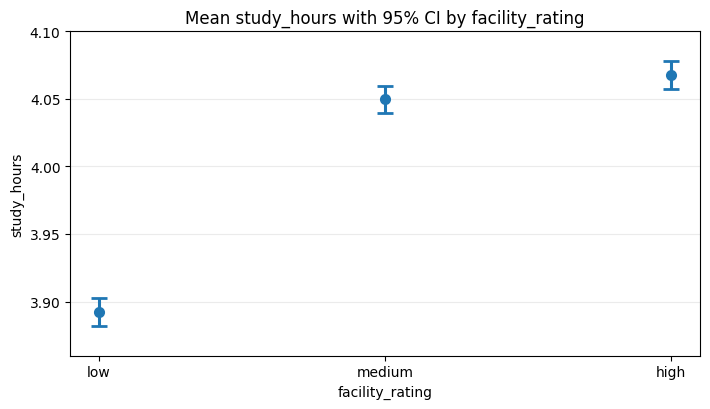

Saved: outputs_study_hours_only/viz1_mean_ci_facility_rating_zoom.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "outputs_study_hours_only"
os.makedirs(OUT_DIR, exist_ok=True)

DV = "study_hours"
IV = "facility_rating"
order = ["low", "medium", "high"]

# ======= (1번) 95% CI + 강제 줌 =======
Y_LIM = (3.86, 4.10)   # ✅ 여기만 조절하면 됨 (더 차이 나게: 더 좁게)

# =========================
# 데이터 준비
# =========================
d = df_base[[DV, IV]].dropna().copy()
d[DV] = pd.to_numeric(d[DV], errors="coerce")
d = d.dropna(subset=[DV])
d = d[d[IV].isin(order)].copy()
d[IV] = pd.Categorical(d[IV], categories=order, ordered=True)

# 그룹 요약(평균, 95% CI)
g = (
    d.groupby(IV, observed=True)[DV]
     .agg(n="count", mean="mean", std="std")
     .reindex(order)
)
g["se"] = g["std"] / np.sqrt(g["n"])
g["ci95"] = 1.96 * g["se"]

display(g)

# =========================
# 평균 + 95% CI (파란 스타일)
# =========================
x = np.arange(len(order))
means = g["mean"].values
ci = g["ci95"].values

plt.figure(figsize=(7.2, 4.2))
plt.errorbar(
    x, means, yerr=ci,
    fmt="o", capsize=6,
    color="tab:blue", ecolor="tab:blue",
    elinewidth=2.2, markeredgewidth=2
)
plt.xticks(x, order)
plt.ylabel(DV)
plt.xlabel(IV)
plt.title(f"Mean {DV} with 95% CI by {IV}")

# ✅ y축 좁게(차이 강조)
plt.ylim(*Y_LIM)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

save_path = os.path.join(OUT_DIR, "viz1_mean_ci_facility_rating_zoom.png")
plt.savefig(save_path, dpi=200)
plt.show()
print("Saved:", save_path)


[Group summary]


,n,mean,std,se,ci95
facility_rating,,,,,
low,212378,3.892176,2.372110,0.005147,0.010089
medium,214082,4.049747,2.331633,0.005039,0.009877
high,203540,4.067418,2.372516,0.005259,0.010307


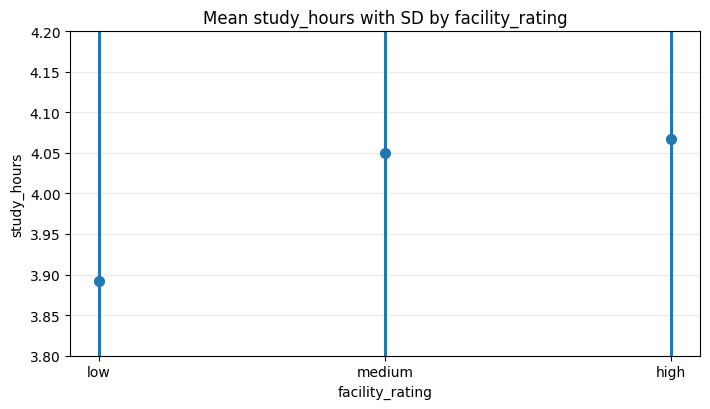

Saved: outputs_study_hours_only/viz1_mean_sd_facility_rating.png


/tmp/ipython-input-3357056699.py:109: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


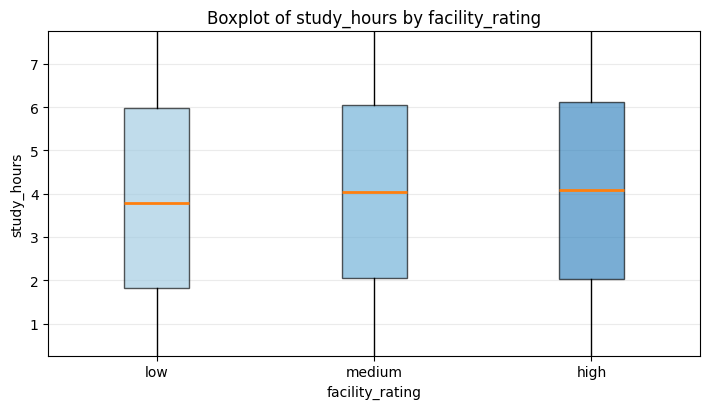

Saved: outputs_study_hours_only/viz2_boxplot_facility_rating.png


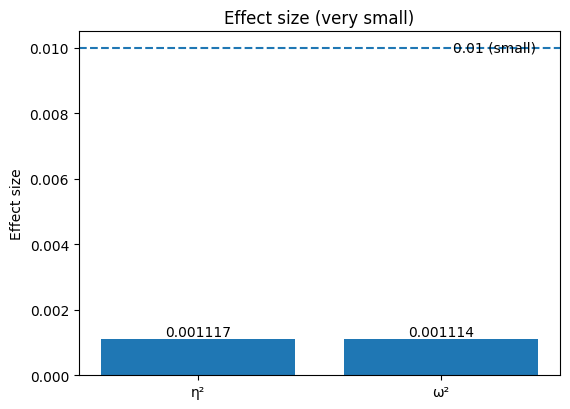

Saved: outputs_study_hours_only/viz3_effect_size_eta_omega.png

[OK] 3 plots saved to: outputs_study_hours_only


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 설정
# =========================
OUT_DIR = "outputs_study_hours_only"
os.makedirs(OUT_DIR, exist_ok=True)

DV = "study_hours"
IV = "facility_rating"
order = ["low", "medium", "high"]

# 효과크기 (복붙 값)
ETA2 = 0.001117
OMEGA2 = 0.001114

# (1) 에러바 모드 선택: "ci" (95% CI) 또는 "sd" (표준편차)
ERRORBAR_MODE = "sd"   # ✅ 발표용 추천: "sd"

# (2) y축 범위 설정
# - "auto": 평균±(에러바)+pad로 자동 줌
# - "manual": 직접 지정한 y축 범위 사용
Y_LIM_MODE = "manual"
Y_LIM = (3.80, 4.20)   # ✅ 발표용으로 차이 강조(원하면 조절)

ZOOM_PAD = 0.15  # auto 모드일 때만 사용

# 박스플롯 y축 줌 분위수 (너무 좁으면 0.05~0.95로)
BOX_Q_LOW = 0.05
BOX_Q_HIGH = 0.95

# =========================
# 데이터 준비
# =========================
d = df_base[[DV, IV]].dropna().copy()
d[DV] = pd.to_numeric(d[DV], errors="coerce")
d = d.dropna(subset=[DV])

d = d[d[IV].isin(order)].copy()
d[IV] = pd.Categorical(d[IV], categories=order, ordered=True)

# 그룹 요약
g = (
    d.groupby(IV, observed=True)[DV]
     .agg(n="count", mean="mean", std="std")
     .reindex(order)
)

# 95% CI
g["se"] = g["std"] / np.sqrt(g["n"])
g["ci95"] = 1.96 * g["se"]

print("[Group summary]")
display(g)

# =========================
# ① 평균 + 에러바 (CI 또는 SD)
# =========================
x = np.arange(len(order))
means = g["mean"].values

if ERRORBAR_MODE.lower() == "ci":
    yerr = g["ci95"].values
    title = f"Mean {DV} with 95% CI by {IV}"
    fname = "viz1_mean_ci_facility_rating.png"
elif ERRORBAR_MODE.lower() == "sd":
    yerr = g["std"].values
    title = f"Mean {DV} with SD by {IV}"
    fname = "viz1_mean_sd_facility_rating.png"
else:
    raise ValueError('ERRORBAR_MODE must be "ci" or "sd".')

plt.figure(figsize=(7.2, 4.2))
plt.errorbar(
    x, means, yerr=yerr,
    fmt="o", capsize=6,
    color="tab:blue", ecolor="tab:blue",
    elinewidth=2.2, markeredgewidth=2,
)
plt.xticks(x, order)
plt.ylabel(DV)
plt.xlabel(IV)
plt.title(title)

# y축 범위
if Y_LIM_MODE == "manual":
    plt.ylim(*Y_LIM)
else:
    y_min = np.min(means - yerr) - ZOOM_PAD
    y_max = np.max(means + yerr) + ZOOM_PAD
    plt.ylim(y_min, y_max)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
path1 = os.path.join(OUT_DIR, fname)
plt.savefig(path1, dpi=200)
plt.show()
print("Saved:", path1)

# =========================
# ② 박스플롯 (색 채움, y축 줌)
# =========================
data = [d.loc[d[IV] == lvl, DV].values for lvl in order]

plt.figure(figsize=(7.2, 4.2))
bp = plt.boxplot(
    data,
    labels=order,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=2)
)

# 박스 색 채움
box_colors = ["#9ecae1", "#6baed6", "#3182bd"]
for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.65)

plt.ylabel(DV)
plt.xlabel(IV)
plt.title(f"Boxplot of {DV} by {IV}")

# 박스플롯 y축 줌(분위수)
all_vals = d[DV].values
q_low, q_high = np.quantile(all_vals, [BOX_Q_LOW, BOX_Q_HIGH])
plt.ylim(q_low - 0.05, q_high + 0.05)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
path2 = os.path.join(OUT_DIR, "viz2_boxplot_facility_rating.png")
plt.savefig(path2, dpi=200)
plt.show()
print("Saved:", path2)

# =========================
# ③ 효과크기(η², ω²) 막대그래프
# =========================
labels = ["η²", "ω²"]
vals = [ETA2, OMEGA2]

plt.figure(figsize=(5.8, 4.2))
bars = plt.bar(labels, vals)

plt.axhline(0.01, linestyle="--", linewidth=1.5)
plt.text(1.05, 0.01, "0.01 (small)", va="center")

plt.ylabel("Effect size")
plt.title("Effect size (very small)")

for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.6f}", ha="center", va="bottom")

plt.tight_layout()
path3 = os.path.join(OUT_DIR, "viz3_effect_size_eta_omega.png")
plt.savefig(path3, dpi=200)
plt.show()
print("Saved:", path3)

print("\n[OK] 3 plots saved to:", OUT_DIR)


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import levene

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# ============================================================
# 설정
# ============================================================
DV = "study_hours"
IV = "facility_rating"         # 학습 시설 만족도
order = ["low", "medium", "high"]

# 층화 샘플링 옵션
USE_STRATIFIED = True          # True: 층화 샘플링 후 분석 / False: 전체 데이터로 분석
SAMPLE_PER_GROUP = 5000     # 그룹당 샘플 수
REPLACE_IF_SMALL = True        # 그룹이 부족하면 복원추출 허용
RANDOM_STATE = 42

# (선택) 반복 층화 샘플링으로 안정성 점검
DO_REPEATS = False             # True로 바꾸면 반복 샘플링 결과 요약까지 출력
N_REPEATS = 200

# ============================================================
# 데이터 준비
# ============================================================
d_full = df[[DV, IV]].dropna().copy()
d_full[DV] = pd.to_numeric(d_full[DV], errors="coerce")
d_full = d_full.dropna(subset=[DV])

d_full[IV] = pd.Categorical(d_full[IV], categories=order, ordered=True)

print("[Full group counts]")
print(d_full[IV].value_counts(dropna=False))
print("n_used_full:", len(d_full))

# ============================================================
# 층화 샘플링
# ============================================================
if USE_STRATIFIED:
    group_sizes = d_full[IV].value_counts()
    min_group = int(group_sizes.min())

    replace = REPLACE_IF_SMALL and (SAMPLE_PER_GROUP > min_group)

    # 비복원인데 표본이 부족하면 자동 축소
    if (not REPLACE_IF_SMALL) and (SAMPLE_PER_GROUP > min_group):
        print(f"[WARN] 어떤 그룹이 {SAMPLE_PER_GROUP}개 미만이라 "
              f"SAMPLE_PER_GROUP를 {min_group}로 낮춥니다 (비복원).")
        SAMPLE_PER_GROUP = min_group
        replace = False

    d = (
        d_full.groupby(IV, group_keys=False)
              .apply(lambda g: g.sample(n=SAMPLE_PER_GROUP, replace=replace, random_state=RANDOM_STATE))
              .reset_index(drop=True)
    )

    print("\n[Stratified sample counts]")
    print(d[IV].value_counts(dropna=False))
    print("n_used_stratified:", len(d))
else:
    d = d_full

# ============================================================
# 1) 일반 ANOVA
# ============================================================
m = smf.ols(f"{DV} ~ C({IV})", data=d).fit()
aov = anova_lm(m, typ=2)

eff = f"C({IV})"
F = float(aov.loc[eff, "F"])
p = float(aov.loc[eff, "PR(>F)"])

# eta^2
ss_total = float(aov["sum_sq"].sum())
eta2 = float(aov.loc[eff, "sum_sq"] / ss_total)

# omega^2
ss_effect = float(aov.loc[eff, "sum_sq"])
df_effect = float(aov.loc[eff, "df"])
ss_error = float(aov.loc["Residual", "sum_sq"])
df_error = float(aov.loc["Residual", "df"])
ms_error = ss_error / df_error
omega2 = float(max(0.0, (ss_effect - df_effect * ms_error) / (ss_total + ms_error)))

anova_result = pd.DataFrame([{
    "model": f"{DV} ~ {IV}" + (" (stratified)" if USE_STRATIFIED else " (full)"),
    "n_used": int(m.nobs),
    "F": F,
    "p": p,
    "eta_squared": eta2,
    "omega_squared": omega2
}])

print("\n=== [ANOVA RESULT] ===")
display(anova_result)

# ============================================================
# 2) 등분산성(Levene)
# ============================================================
groups = [d.loc[d[IV] == g, DV].astype(float) for g in order if (d[IV] == g).any()]
stat_lv, p_lv = levene(*groups, center="median")
print(f"\n[Levene test] stat={stat_lv:.4f}, p={p_lv:.4g}")

# ============================================================
# 3) Robust(HC3) ANOVA-like TEST
# ============================================================
aov_rob = anova_lm(m, typ=2, robust="hc3")
F_r = float(aov_rob.loc[eff, "F"])
p_r = float(aov_rob.loc[eff, "PR(>F)"])

robust_result = pd.DataFrame([{
    "model": f"{DV} ~ {IV} (robust HC3)",
    "F_robust": F_r,
    "p_robust": p_r
}])

print("\n=== [Robust (HC3) ANOVA-like TEST] ===")
display(robust_result)

# ============================================================
# 4) 사후검정
# ============================================================
if p_lv < 0.05:
    print("\n[Post-hoc] 등분산 위반 가능 → Games-Howell 권장")
    try:
        import pingouin as pg
        gh = pg.pairwise_gameshowell(data=d, dv=DV, between=IV)
        display(gh)
    except Exception as e:
        print("pingouin이 없어서 Games-Howell 실행 불가:", e)
        print("pip install pingouin 후 다시 실행해줘.")
else:
    print("\n[Post-hoc] 등분산 가정 크게 문제 없음 → Tukey HSD")
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tuk = pairwise_tukeyhsd(endog=d[DV].astype(float), groups=d[IV].astype(str), alpha=0.05)
    print(tuk)

# ============================================================
# (선택) 반복 층화 샘플링 안정성 점검
# ============================================================
if USE_STRATIFIED and DO_REPEATS:
    rows = []
    group_sizes = d_full[IV].value_counts()
    min_group = int(group_sizes.min())
    replace = REPLACE_IF_SMALL and (SAMPLE_PER_GROUP > min_group)

    for seed in range(N_REPEATS):
        d_rep = (
            d_full.groupby(IV, group_keys=False)
                  .apply(lambda g: g.sample(n=SAMPLE_PER_GROUP, replace=replace, random_state=seed))
                  .reset_index(drop=True)
        )

        m_rep = smf.ols(f"{DV} ~ C({IV})", data=d_rep).fit()
        aov_rep = anova_lm(m_rep, typ=2)

        F_ = float(aov_rep.loc[eff, "F"])
        p_ = float(aov_rep.loc[eff, "PR(>F)"])

        ss_total_ = float(aov_rep["sum_sq"].sum())
        ss_effect_ = float(aov_rep.loc[eff, "sum_sq"])
        df_effect_ = float(aov_rep.loc[eff, "df"])
        ss_error_ = float(aov_rep.loc["Residual", "sum_sq"])
        df_error_ = float(aov_rep.loc["Residual", "df"])
        ms_error_ = ss_error_ / df_error_

        eta2_ = ss_effect_ / ss_total_
        omega2_ = float(max(0.0, (ss_effect_ - df_effect_ * ms_error_) / (ss_total_ + ms_error_)))

        rows.append({
            "seed": seed,
            "n": int(m_rep.nobs),
            "F": F_,
            "p": p_,
            "eta2": eta2_,
            "omega2": omega2_
        })

    rep_df = pd.DataFrame(rows)
    print("\n=== [Repeated Stratified Sampling Summary] ===")
    display(rep_df.describe(percentiles=[0.05, 0.5, 0.95]))
    print("p<0.05 비율:", (rep_df["p"] < 0.05).mean())


[Full group counts]
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64
n_used_full: 630000

[Stratified sample counts]
facility_rating
low       5000
medium    5000
high      5000
Name: count, dtype: int64
n_used_stratified: 15000

=== [ANOVA RESULT] ===


/tmp/ipython-input-2389832924.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d_full.groupby(IV, group_keys=False)
/tmp/ipython-input-2389832924.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=SAMPLE_PER_GROUP, replace=replace, random_state=RANDOM_STATE))


,model,n_used,F,p,eta_squared,omega_squared
0,study_hours ~ facility_rating (stratified),15000,7.378019,0.000627,0.000983,0.00085



[Levene test] stat=0.7437, p=0.4754

=== [Robust (HC3) ANOVA-like TEST] ===


,model,F_robust,p_robust
0,study_hours ~ facility_rating (robust HC3),7.322218,0.000663



[Post-hoc] 등분산 가정 크게 문제 없음 → Tukey HSD
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -0.1755 0.0006 -0.2859 -0.0651   True
  high medium  -0.0498 0.5404 -0.1602  0.0606  False
   low medium   0.1257 0.0208  0.0153  0.2361   True
----------------------------------------------------
